In [1]:
# ============================================================================
# CELL 1: SETUP, INSTALL LPIPS, MODEL LOADING (HUGGING FACE), AND EVALUATION FUNCTION
# ============================================================================

import os
import sys
import subprocess
import gc

# ---------------------------
# 1. Install LPIPS if missing (BEFORE importing it)
# ---------------------------
try:
    import lpips
except ImportError:
    print("📦 Installing lpips...")
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'lpips'], check=True)
    import lpips
    print("✅ lpips installed.")

# Now import all other packages
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# ---------------------------
# 2. Device
# ---------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ---------------------------
# 3. MIMO-UNet Architecture
# ---------------------------
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))

class MIMOUNet(nn.Module):
    def __init__(self, num_res=8):
        super().__init__()
        self.enc1 = nn.Conv2d(3, 32, 3, padding=1)
        self.enc1_blocks = nn.Sequential(*[BasicBlock(32, 32) for _ in range(num_res)])
        self.down1 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.enc2_in = nn.Conv2d(3+64, 64, 1)
        self.enc2_blocks = nn.Sequential(*[BasicBlock(64, 64) for _ in range(num_res)])
        self.down2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.enc3_in = nn.Conv2d(3+128, 128, 1)
        self.enc3_blocks = nn.Sequential(*[BasicBlock(128, 128) for _ in range(num_res)])
        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.dec2_blocks = nn.Sequential(*[BasicBlock(64, 64) for _ in range(num_res)])
        self.out2 = nn.Conv2d(64, 3, 3, padding=1)   # auxiliary output (not used)
        self.up1 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.dec1_blocks = nn.Sequential(*[BasicBlock(32, 32) for _ in range(num_res)])
        self.out1 = nn.Conv2d(32, 3, 3, padding=1)
        
    def forward(self, x):
        x_half = F.interpolate(x, scale_factor=0.5, mode='bilinear', align_corners=False)
        x_quarter = F.interpolate(x_half, scale_factor=0.5, mode='bilinear', align_corners=False)
        e1 = self.enc1_blocks(self.enc1(x))
        e2 = self.enc2_blocks(self.enc2_in(torch.cat([self.down1(e1), x_half], dim=1)))
        e3 = self.enc3_blocks(self.enc3_in(torch.cat([self.down2(e2), x_quarter], dim=1)))
        d2 = self.dec2_blocks(self.up2(e3) + e2)
        d1 = self.dec1_blocks(self.up1(d2) + e1)
        return self.out1(d1)   # final output

# ---------------------------
# 4. Load pretrained weights from Hugging Face
# ---------------------------
model = MIMOUNet(num_res=8).to(device)
WEIGHTS_URL = "https://huggingface.co/Shafi99/iPhoneBlur_Finetune_Models/resolve/main/mimo_final_weights.pth"
WEIGHTS_PATH = "mimo_final_weights.pth"

if not os.path.exists(WEIGHTS_PATH):
    print("⬇️ Downloading weights from Hugging Face...")
    subprocess.run(['wget', '-q', '-O', WEIGHTS_PATH, WEIGHTS_URL], check=True)
    
ckpt = torch.load(WEIGHTS_PATH, map_location=device)
if 'model_state_dict' in ckpt:
    model.load_state_dict(ckpt['model_state_dict'])
elif 'params' in ckpt:
    model.load_state_dict(ckpt['params'])
else:
    model.load_state_dict(ckpt)
print("✅ Model weights loaded successfully from Hugging Face.")

# ---------------------------
# 5. Verify model forward pass with a dummy tensor
# ---------------------------
dummy = torch.randn(1, 3, 256, 256).to(device)
with torch.no_grad():
    out = model(dummy)
print(f"✅ Model forward pass verified. Output shape: {out.shape}")

# ---------------------------
# 6. Dataset class (supports padding and returns original size)
# ---------------------------
class iPhoneBlurTestDataset(Dataset):
    def __init__(self, data_dir, pad_to=16):
        self.data_dir = Path(data_dir)
        self.blur_paths = sorted(list(self.data_dir.rglob('blur/*.jpg')) + list(self.data_dir.rglob('blur/*.png')))
        self.sharp_paths = sorted(list(self.data_dir.rglob('sharp/*.jpg')) + list(self.data_dir.rglob('sharp/*.png')))
        self.pad_to = pad_to
    
    def __len__(self):
        return len(self.blur_paths)
    
    def __getitem__(self, idx):
        blur = cv2.cvtColor(cv2.imread(str(self.blur_paths[idx])), cv2.COLOR_BGR2RGB)
        sharp = cv2.cvtColor(cv2.imread(str(self.sharp_paths[idx])), cv2.COLOR_BGR2RGB)
        h, w, _ = blur.shape
        pad_h = (self.pad_to - h % self.pad_to) % self.pad_to
        pad_w = (self.pad_to - w % self.pad_to) % self.pad_to
        if pad_h > 0 or pad_w > 0:
            blur = np.pad(blur, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
        blur_t = torch.from_numpy(blur).float().permute(2, 0, 1) / 255.0
        sharp_t = torch.from_numpy(sharp).float().permute(2, 0, 1) / 255.0
        return blur_t, sharp_t, str(self.blur_paths[idx]), h, w

# ---------------------------
# 7. Evaluation function with live progress bar
# ---------------------------
def evaluate_test_set(model, test_loader, device, metadata_df=None):
    model.eval()
    lpips_fn = lpips.LPIPS(net='alex').to(device)
    results = []
    
    print("🚀 Starting evaluation (OOM-safe mode)...")
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Evaluating", dynamic_ncols=True)
        running_psnr = 0.0
        running_ssim = 0.0
        running_lpips = 0.0
        num_batches = 0
        
        for blur_pad, sharp, paths, orig_h, orig_w in pbar:
            blur_pad, sharp = blur_pad.to(device), sharp.to(device)
            with torch.autocast(device_type='cuda'):
                output = model(blur_pad)
            
            if isinstance(output, (tuple, list)):
                output = output[0]
            
            h, w = orig_h[0].item(), orig_w[0].item()
            output = output[:, :, :h, :w]
            output_clamped = torch.clamp(output, 0, 1).float()
            
            # LPIPS (expects inputs in [-1, 1])
            l_val = lpips_fn(output_clamped * 2.0 - 1.0, sharp * 2.0 - 1.0).item()
            
            # PSNR and SSIM
            out_np = output_clamped[0].cpu().numpy().transpose(1, 2, 0)
            gt_np = sharp[0].cpu().numpy().transpose(1, 2, 0)
            p_val = psnr_metric(gt_np, out_np, data_range=1.0)
            s_val = ssim_metric(gt_np, out_np, data_range=1.0, channel_axis=2, win_size=11)
            
            # Build img_id for merging with metadata
            full_path = Path(paths[0])
            video_name = full_path.parent.parent.name   # e.g., "IMG_2139"
            frame_num = full_path.stem                   # e.g., "00000"
            img_id = f"{video_name}_{frame_num}"
            
            results.append({
                'img_id': img_id,
                'filename': full_path.name,
                'psnr': p_val,
                'ssim': s_val,
                'lpips': l_val
            })
            
            # Update running averages for progress bar
            num_batches += 1
            running_psnr += (p_val - running_psnr) / num_batches
            running_ssim += (s_val - running_ssim) / num_batches
            running_lpips += (l_val - running_lpips) / num_batches
            pbar.set_postfix({
                'PSNR': f'{running_psnr:.2f}',
                'SSIM': f'{running_ssim:.4f}',
                'LPIPS': f'{running_lpips:.4f}'
            })
            
            # Cleanup to avoid OOM
            del blur_pad, output, output_clamped, sharp
            gc.collect()
            torch.cuda.empty_cache()
    
    results_df = pd.DataFrame(results)
    
    if metadata_df is not None:
        # Merge on img_id
        results_df = pd.merge(results_df, metadata_df, on='img_id', how='left', suffixes=('', '_meta'))
        if 'difficulty' in results_df.columns:
            print("\n✅ Stratified Results (Easy / Medium / Hard):")
            stats = results_df.groupby('difficulty')[['psnr', 'ssim', 'lpips']].mean().reindex(['Easy', 'Medium', 'Hard'])
            print(stats.round(4))
        else:
            print("\n⚠️ 'difficulty' column not found in metadata.")
    else:
        print("\n📊 Overall Results (no metadata provided):")
        print(results_df[['psnr', 'ssim', 'lpips']].mean().round(4))
    
    return results_df

print("\n✅ Cell 1 ready. Model loaded, evaluation function defined.")

Using device: cuda
✅ Model weights loaded successfully from Hugging Face.
✅ Model forward pass verified. Output shape: torch.Size([1, 3, 256, 256])

✅ Cell 1 ready. Model loaded, evaluation function defined.


In [2]:
# ============================================================================
# CELL 2: FULL TEST SET EVALUATION (STRATIFIED + OVERALL ONLY)
# ============================================================================

TEST_DIR = '/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/test'
META_PATH = '/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/metadata/test_metadata.csv'

if not Path(TEST_DIR).exists():
    raise FileNotFoundError(f"Test directory not found: {TEST_DIR}")

# Load metadata
metadata_df = None
if Path(META_PATH).exists():
    metadata_df = pd.read_csv(META_PATH)
    print(f"📊 Metadata loaded: {len(metadata_df)} samples")
else:
    print(f"⚠️ Metadata not found – stratified results unavailable.")

# Create dataset and loader
test_dataset = iPhoneBlurTestDataset(TEST_DIR, pad_to=16)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"📦 Test dataset size: {len(test_dataset)} images\n")

# Run evaluation (this will print stratified results + overall only)
results_df = evaluate_test_set(model, test_loader, device, metadata_df=metadata_df)

# Save detailed CSV (optional – no console output)
results_df.to_csv('MIMO_UNet_iPhoneBlur_Results.csv', index=False)

📊 Metadata loaded: 1686 samples
📦 Test dataset size: 1686 images

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
🚀 Starting evaluation (OOM-safe mode)...


Evaluating:   0%|          | 0/1686 [00:00<?, ?it/s]


✅ Stratified Results (Easy / Medium / Hard):
               psnr    ssim   lpips
difficulty                         
Easy        33.9317  0.9730  0.0367
Medium      29.7138  0.9327  0.0840
Hard        25.7329  0.8607  0.1567


✅ Loaded from iPhoneBlur/train/IMG_2983/00173.jpg -> Unknown
✅ Loaded from iPhoneBlur/train/IMG_2190/00447.jpg -> Unknown
✅ Loaded from iPhoneBlur/train/IMG_2194/00171.jpg -> Unknown

🔬 Generating qualitative grid for 3 samples...


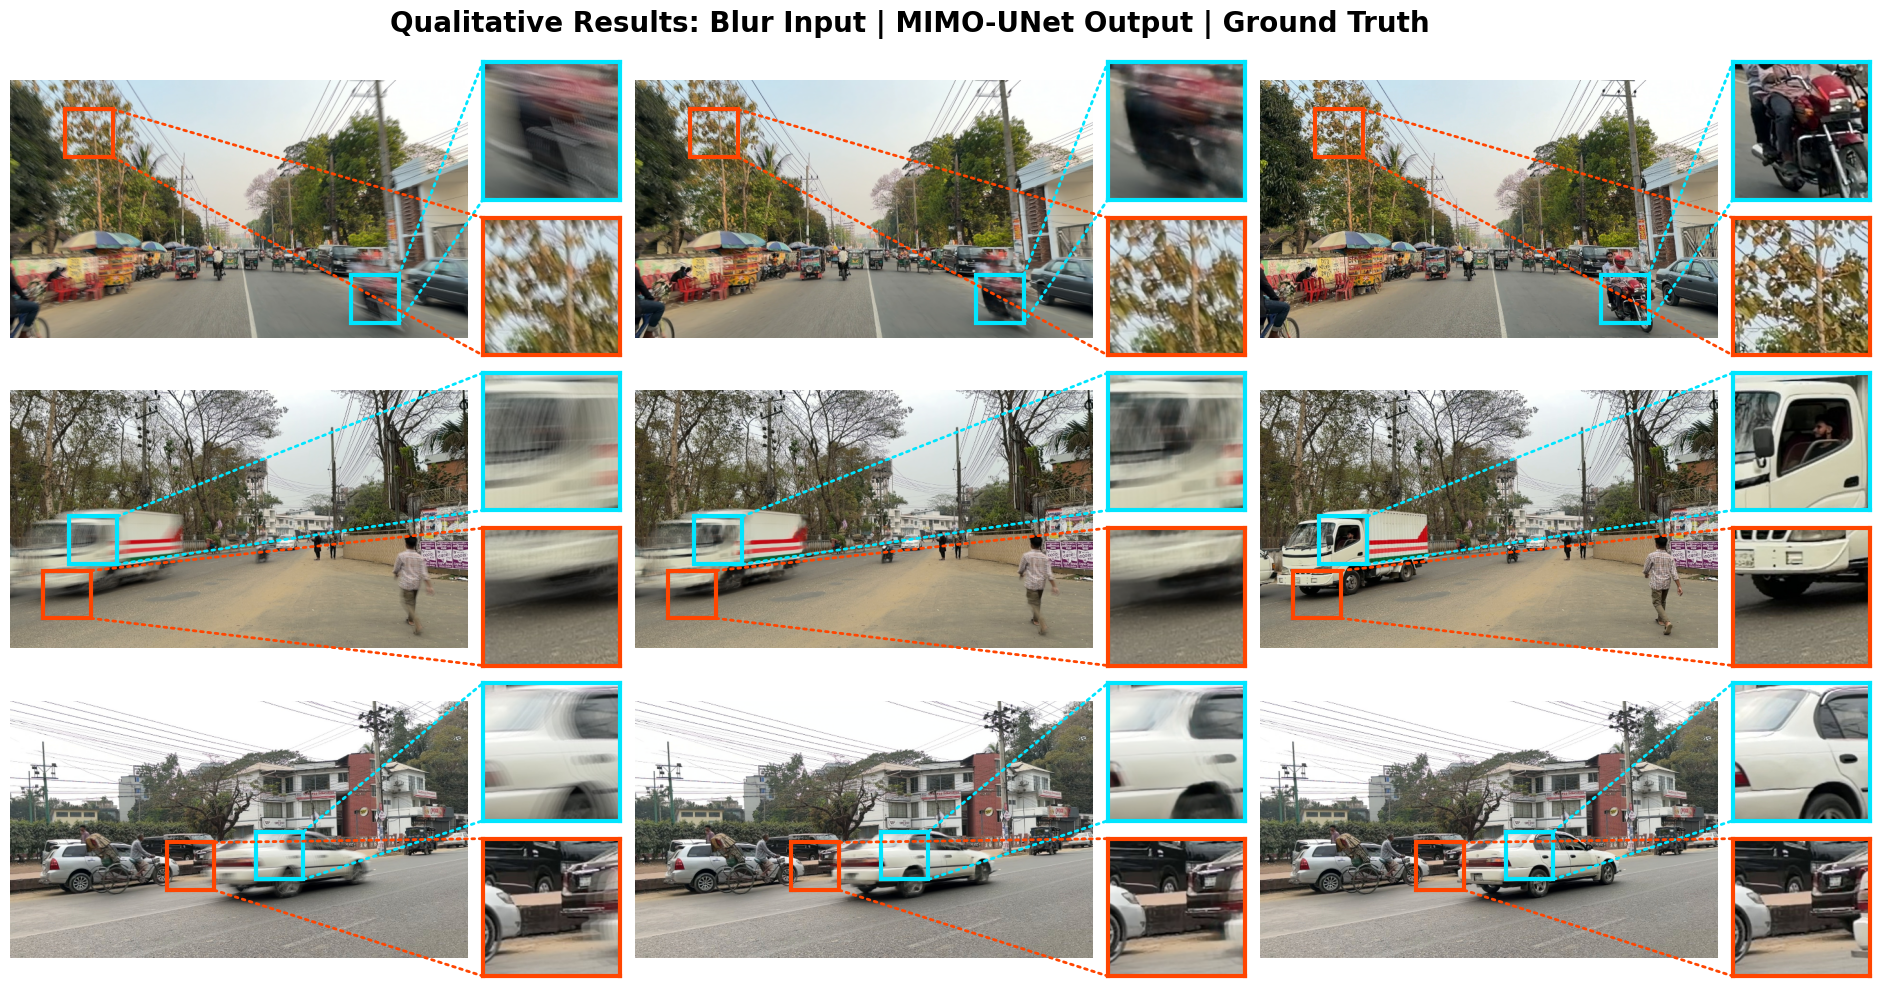

In [6]:
# ============================================================================
# CELL 3: QUALITATIVE GRID FOR YOUR 3 SPECIFIC IMAGES (SEARCH TRAIN + TEST)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, ConnectionPatch
from pathlib import Path
import numpy as np
import cv2
import torch
import gc

def draw_connections(ax_main, ax_patch, box_x, box_y, box_w, box_h, color):
    con1 = ConnectionPatch(xyA=(box_x + box_w, box_y), xyB=(0, 1),
                           coordsA="data", coordsB="axes fraction",
                           axesA=ax_main, axesB=ax_patch, color=color,
                           linestyle='dotted', linewidth=2)
    con2 = ConnectionPatch(xyA=(box_x + box_w, box_y + box_h), xyB=(0, 0),
                           coordsA="data", coordsB="axes fraction",
                           axesA=ax_main, axesB=ax_patch, color=color,
                           linestyle='dotted', linewidth=2)
    ax_main.add_artist(con1)
    ax_main.add_artist(con2)

def generate_qualitative_grid(model, sample_list, device, patch_size=200, pad_to=16):
    print(f"\n🔬 Generating qualitative grid for {len(sample_list)} samples...")
    model.eval()
    sample_data = []
    colors = ['#00E5FF', '#FF4500']
    
    for blur_path, sharp_path, diff in sample_list:
        blur_full = cv2.cvtColor(cv2.imread(str(blur_path)), cv2.COLOR_BGR2RGB)
        sharp_full = cv2.cvtColor(cv2.imread(str(sharp_path)), cv2.COLOR_BGR2RGB)
        h, w, _ = blur_full.shape
        pad_h = (pad_to - h % pad_to) % pad_to
        pad_w = (pad_to - w % pad_to) % pad_to
        
        if pad_h > 0 or pad_w > 0:
            img_pad = np.pad(blur_full, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
        else:
            img_pad = blur_full
        
        inp = torch.from_numpy(img_pad).float().permute(2,0,1).unsqueeze(0).to(device) / 255.0
        
        with torch.no_grad():
            with torch.autocast(device_type='cuda'):
                out = model(inp)
            if isinstance(out, (tuple, list)):
                out = out[0]
            out = out.cpu()
            del inp
            torch.cuda.empty_cache()
        
        model_out = (np.clip(out.squeeze(0).float().permute(1,2,0).numpy()[:h, :w], 0, 1) * 255).astype(np.uint8)
        
        # Select two high-error patches
        diff_map = np.abs(sharp_full.astype(float) - blur_full.astype(float)).mean(axis=2)
        boxes = []
        for _ in range(2):
            best_y, best_x, best_s = 0, 0, -1
            for _ in range(50):
                y = np.random.randint(0, max(1, h - patch_size))
                x = np.random.randint(0, max(1, w - patch_size))
                if any(abs(y-by) < patch_size and abs(x-bx) < patch_size for by, bx in boxes):
                    continue
                s = diff_map[y:y+patch_size, x:x+patch_size].mean()
                if s > best_s:
                    best_y, best_x, best_s = y, x, s
            boxes.append((best_y, best_x))
        
        sample_data.append({'diff': diff, 'blur': blur_full, 'out': model_out, 'sharp': sharp_full, 'boxes': boxes})
        gc.collect()
    
    DPI, TGT_H = 100, 400
    n_rows = len(sample_data) * 2
    fig = plt.figure(figsize=(24, n_rows * (patch_size/DPI)), dpi=DPI)
    gs = gridspec.GridSpec(n_rows, 6, figure=fig,
                           width_ratios=[1, 0.3, 1, 0.3, 1, 0.3],
                           wspace=0.05, hspace=0.05)
    
    for idx, data in enumerate(sample_data):
        row_start = idx * 2
        for col_idx, img_key in enumerate(['blur', 'out', 'sharp']):
            img = data[img_key]
            ax_main = fig.add_subplot(gs[row_start:row_start+2, col_idx*2])
            ax_main.imshow(cv2.resize(img, (int(img.shape[1] * TGT_H / img.shape[0]), TGT_H)), aspect='equal')
            if col_idx == 0:
                ax_main.set_ylabel(f"{data['diff']} Sample", fontsize=16, fontweight='bold')
            ax_main.axis('off')
            
            scale = TGT_H / img.shape[0]
            ps_scaled = patch_size * scale
            for p_idx, ((by, bx), col) in enumerate(zip(data['boxes'], colors)):
                ax_main.add_patch(Rectangle((bx*scale, by*scale), ps_scaled, ps_scaled,
                                             linewidth=3, edgecolor=col, facecolor='none'))
                ax_patch = fig.add_subplot(gs[row_start+p_idx, col_idx*2+1])
                ax_patch.imshow(img[by:by+patch_size, bx:bx+patch_size])
                for sp in ax_patch.spines.values():
                    sp.set_edgecolor(col)
                    sp.set_linewidth(3)
                ax_patch.set_xticks([])
                ax_patch.set_yticks([])
                draw_connections(ax_main, ax_patch, bx*scale, by*scale, ps_scaled, ps_scaled, col)
    
    plt.suptitle(f"Qualitative Results: Blur Input | MIMO-UNet Output | Ground Truth",
                 fontsize=20, fontweight='bold', y=0.92)
    plt.show()

# =============== YOUR 3 SPECIFIC IMAGES ===============
image_specs = [
    ("IMG_2983", "00173"),
    ("IMG_2190", "00447"),
    ("IMG_2194", "00171")
]

# Search in both test and train directories
splits = ['test', 'train']
base_paths = [Path(f'/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/{split}') for split in splits]

# Load metadata (for difficulty labels)
if 'metadata_df' not in dir() or metadata_df is None:
    meta_path = Path('/kaggle/input/datasets/shafi09/iphoneblur/iPhoneBlur/metadata/complete_metadata.csv')
    if meta_path.exists():
        import pandas as pd
        metadata_df = pd.read_csv(meta_path)
        metadata_df['img_id'] = metadata_df['img_id'].astype(str)
    else:
        metadata_df = None

sample_list = []

for dir_base, frame in image_specs:
    found = False
    for base in base_paths:
        # Try folder name with and without .MOV
        for folder_name in [dir_base, f"{dir_base}.MOV"]:
            blur_path = base / folder_name / 'blur' / f"{frame}.jpg"
            sharp_path = base / folder_name / 'sharp' / f"{frame}.jpg"
            if blur_path.exists() and sharp_path.exists():
                img_id = f"{dir_base}_{frame}"
                if metadata_df is not None and img_id in metadata_df['img_id'].values:
                    diff = metadata_df[metadata_df['img_id'] == img_id]['difficulty'].values[0]
                else:
                    diff = "Unknown"
                sample_list.append((blur_path, sharp_path, diff))
                print(f"✅ Loaded from {base.parent.name}/{base.name}/{folder_name}/{frame}.jpg -> {diff}")
                found = True
                break
        if found:
            break
    if not found:
        print(f"❌ Could not find {dir_base}_{frame} in test or train directories.")

if len(sample_list) == 3:
    generate_qualitative_grid(model, sample_list, device, patch_size=200, pad_to=16)
else:
    print(f"❌ Only {len(sample_list)} of 3 images found. Cannot generate grid.")